# Olist Dataset — Exploratory Data Analysis

Purpose: understand and validate the raw Olist e-commerce dataset thoroughly enough to design the Causa data model and KPI layer. This notebook does not build any application logic, agents, or database schema — it is pure data exploration.

Sections:
1. Load all tables
2. Shape, dtypes, and schema overview
3. Null / missing value analysis
4. Duplicate and primary key checks
5. Referential integrity across tables (foreign keys)
6. Date range and time coverage
7. Key distributions (orders, payments, reviews, products, geography)
8. Notes toward the Causa data model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_DIR = Path("..") / "data" / "raw" / "olist"
DATA_DIR

WindowsPath('../data/raw/olist')

## 1. Load all tables

Expects the raw Olist CSVs to already be extracted into `data/raw/olist/` (see repo README).

In [2]:
TABLES = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

dfs = {}
for name, filename in TABLES.items():
    path = DATA_DIR / filename
    if path.exists():
        dfs[name] = pd.read_csv(path)
    else:
        print(f"MISSING: {filename}")

list(dfs.keys())

['customers',
 'orders',
 'order_items',
 'order_payments',
 'order_reviews',
 'products',
 'sellers',
 'geolocation',
 'category_translation']

## 2. Shape, dtypes, and schema overview

In [3]:
for name, df in dfs.items():
    print(f"{name:22} rows={df.shape[0]:>8,}  cols={df.shape[1]:>3}")

customers              rows=  99,441  cols=  5
orders                 rows=  99,441  cols=  8
order_items            rows= 112,650  cols=  7
order_payments         rows= 103,886  cols=  5
order_reviews          rows=  99,224  cols=  7
products               rows=  32,951  cols=  9
sellers                rows=   3,095  cols=  4
geolocation            rows=1,000,163  cols=  5
category_translation   rows=      71  cols=  2


In [4]:
# Inspect one table's schema at a time by changing the key below
dfs["orders"].dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [5]:
dfs["orders"].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 3. Null / missing value analysis

In [6]:
def null_report(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    report = pd.DataFrame({
        "n_null": df.isna().sum(),
        "null_rate": (df.isna().sum() / n).round(4),
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(),
    })
    return report.sort_values("null_rate", ascending=False)

for name, df in dfs.items():
    rep = null_report(df)
    if rep["n_null"].sum() > 0:
        print(f"\n=== {name} (columns with nulls) ===")
        display(rep[rep["n_null"] > 0])


=== orders (columns with nulls) ===


,n_null,null_rate,dtype,n_unique
order_delivered_customer_date,2965,0.0298,object,95664
order_delivered_carrier_date,1783,0.0179,object,81018
order_approved_at,160,0.0016,object,90733



=== order_reviews (columns with nulls) ===


,n_null,null_rate,dtype,n_unique
review_comment_title,87656,0.8834,object,4527
review_comment_message,58247,0.5870,object,36159



=== products (columns with nulls) ===


,n_null,null_rate,dtype,n_unique
product_category_name,610,0.0185,object,73
product_description_lenght,610,0.0185,float64,2960
product_name_lenght,610,0.0185,float64,66
product_photos_qty,610,0.0185,float64,19
product_weight_g,2,0.0001,float64,2204
product_height_cm,2,0.0001,float64,102
product_length_cm,2,0.0001,float64,99
product_width_cm,2,0.0001,float64,95


## 4. Duplicate and primary key checks

In [7]:
PRIMARY_KEYS = {
    "customers": ["customer_id"],
    "orders": ["order_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "category_translation": ["product_category_name"],
}

for name, pk in PRIMARY_KEYS.items():
    df = dfs[name]
    full_dupes = df.duplicated().sum()
    pk_dupes = df.duplicated(subset=pk).sum()
    print(f"{name:22} full_row_dupes={full_dupes:>6}  pk_dupes({pk})={pk_dupes:>6}")

customers              full_row_dupes=     0  pk_dupes(['customer_id'])=     0
orders                 full_row_dupes=     0  pk_dupes(['order_id'])=     0


order_items            full_row_dupes=     0  pk_dupes(['order_id', 'order_item_id'])=     0
order_payments         full_row_dupes=     0  pk_dupes(['order_id', 'payment_sequential'])=     0
order_reviews          full_row_dupes=     0  pk_dupes(['review_id'])=   814


products               full_row_dupes=     0  pk_dupes(['product_id'])=     0
sellers                full_row_dupes=     0  pk_dupes(['seller_id'])=     0
category_translation   full_row_dupes=     0  pk_dupes(['product_category_name'])=     0


## 5. Referential integrity across tables

For each foreign key relationship, count how many child-side keys have no match in the parent table (orphans).

In [8]:
FOREIGN_KEYS = [
    ("orders", "customer_id", "customers", "customer_id"),
    ("order_items", "order_id", "orders", "order_id"),
    ("order_items", "product_id", "products", "product_id"),
    ("order_items", "seller_id", "sellers", "seller_id"),
    ("order_payments", "order_id", "orders", "order_id"),
    ("order_reviews", "order_id", "orders", "order_id"),
    ("products", "product_category_name", "category_translation", "product_category_name"),
]

for child_table, child_col, parent_table, parent_col in FOREIGN_KEYS:
    child_keys = set(dfs[child_table][child_col].dropna().unique())
    parent_keys = set(dfs[parent_table][parent_col].dropna().unique())
    orphans = child_keys - parent_keys
    rate = len(orphans) / len(child_keys) if child_keys else 0
    print(f"{child_table}.{child_col:25} -> {parent_table}.{parent_col:25} orphans={len(orphans):>6} ({rate:.2%})")

orders.customer_id               -> customers.customer_id               orphans=     0 (0.00%)
order_items.order_id                  -> orders.order_id                  orphans=     0 (0.00%)


order_items.product_id                -> products.product_id                orphans=     0 (0.00%)
order_items.seller_id                 -> sellers.seller_id                 orphans=     0 (0.00%)


order_payments.order_id                  -> orders.order_id                  orphans=     0 (0.00%)
order_reviews.order_id                  -> orders.order_id                  orphans=     0 (0.00%)
products.product_category_name     -> category_translation.product_category_name     orphans=     2 (2.74%)


## 6. Date range and time coverage

Orders table carries the core lifecycle timestamps. Confirm the overall coverage window and look for anomalies (e.g. delivery before purchase).

In [9]:
orders = dfs["orders"].copy()
date_cols = [c for c in orders.columns if "date" in c or "timestamp" in c]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

for c in date_cols:
    print(f"{c:35} min={orders[c].min()}  max={orders[c].max()}")

order_purchase_timestamp            min=2016-09-04 21:15:19  max=2018-10-17 17:30:18
order_delivered_carrier_date        min=2016-10-08 10:34:01  max=2018-09-11 19:48:28
order_delivered_customer_date       min=2016-10-11 13:46:32  max=2018-10-17 13:22:46
order_estimated_delivery_date       min=2016-09-30 00:00:00  max=2018-11-12 00:00:00


In [10]:
# Sanity check: delivered orders where delivery timestamp precedes purchase timestamp
bad_delivery = orders[
    orders["order_delivered_customer_date"].notna()
    & (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"])
]
print(f"orders with delivery before purchase: {len(bad_delivery)}")

# order_status distribution
dfs["orders"]["order_status"].value_counts()

orders with delivery before purchase: 0


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 7. Key distributions

Orders per month, payment types/values, review scores, product categories, seller/customer geography.

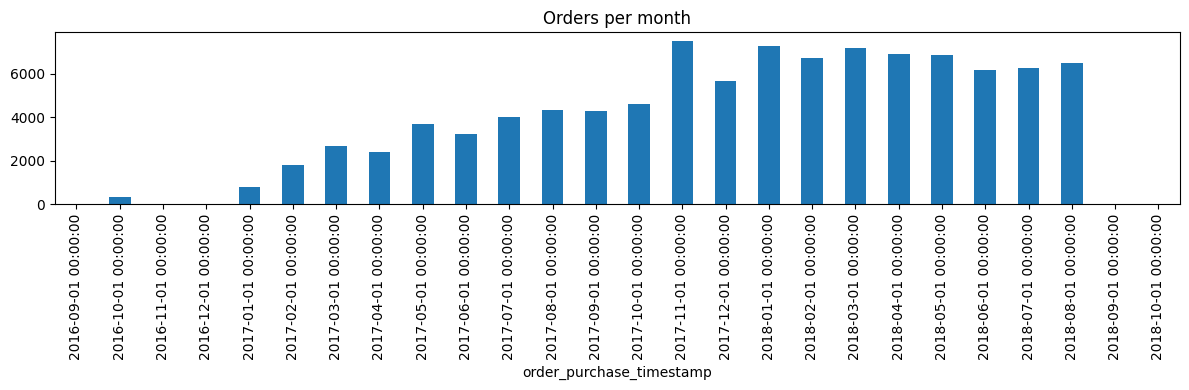

In [11]:
orders_by_month = (
    orders.set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
)
orders_by_month.plot(kind="bar", figsize=(12, 4), title="Orders per month")
plt.tight_layout()
plt.show()

In [12]:
display(dfs["order_payments"]["payment_type"].value_counts())
dfs["order_payments"]["payment_value"].describe()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

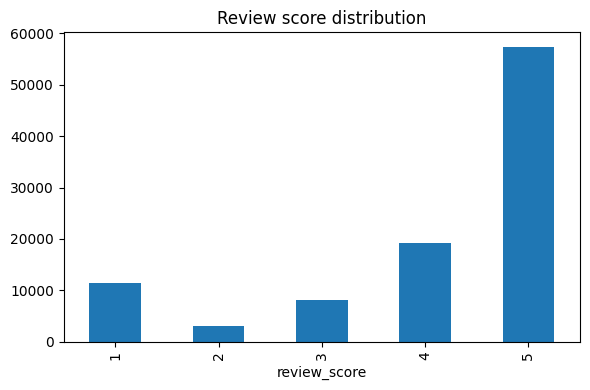

In [13]:
dfs["order_reviews"]["review_score"].value_counts().sort_index().plot(
    kind="bar", figsize=(6, 4), title="Review score distribution"
)
plt.tight_layout()
plt.show()

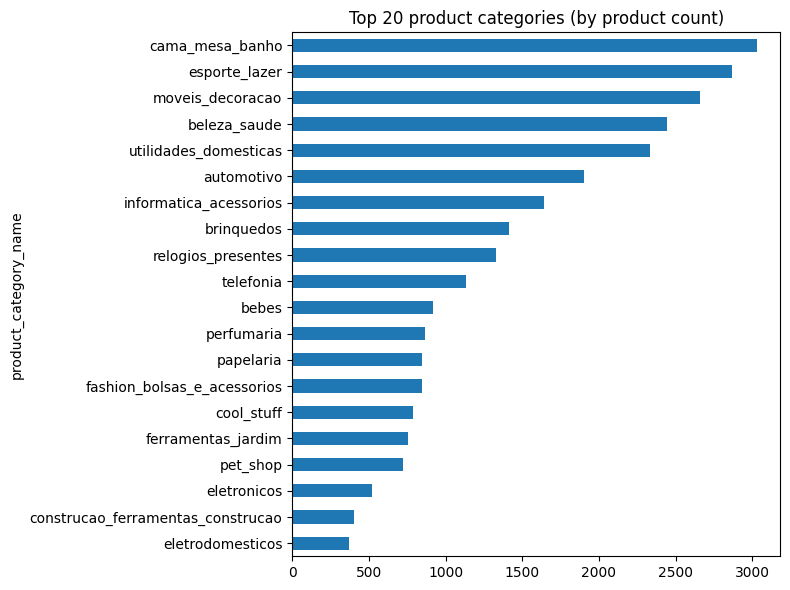

In [14]:
dfs["products"]["product_category_name"].value_counts().head(20).plot(
    kind="barh", figsize=(8, 6), title="Top 20 product categories (by product count)"
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
display(dfs["customers"]["customer_state"].value_counts().head(10))
display(dfs["sellers"]["seller_state"].value_counts().head(10))

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64

## 8. Notes toward the Causa data model

Capture observations here as they emerge (grain of each table, candidate fact/dimension split, known data quality caveats to carry into `docs/DATA_MODEL.md` and `docs/DATA_QUALITY_REPORT.md`).

- `orders` is one row per order (order_id), status + 8 lifecycle timestamps — the central fact table's anchor. Zero orphan `customer_id` references; no delivery-before-purchase anomalies found.
- `order_items` is one row per line item (order_id, order_item_id) — grain is finer than orders; needed for revenue/product KPIs.
- `order_payments` can have multiple rows per order (installments/split payment types) — do not join naively without aggregating.
- `order_reviews` has 814 duplicate `review_id` values and 547 orders with more than one review — `review_id` is **not** a clean primary key; verify before treating it as one.
- `customers` has both `customer_id` (per order) and `customer_unique_id` (per person) — 99,441 order-scoped IDs map to only 96,096 unique people, confirming repeat customers exist. Use `customer_unique_id` for customer-level KPIs (e.g. repeat purchase rate).
- `geolocation` is a zip-prefix lookup, not row-per-entity, and is 26.2% exact duplicates — needs aggregation (e.g. mean lat/lng per prefix) before joining.
- 2 product categories (`pc_gamer`, `portateis_cozinha_e_preparadores_de_alimentos`) are missing from `category_translation` — patch or handle nulls gracefully.
- Full findings are captured in `docs/DATA_QUALITY_REPORT.md`; the resulting entity design is in `docs/DATA_MODEL.md`.